--- FINANCIAL PROCURE-TO-PAY AUDIT ---

--- CASH LEAKAGE AUDIT ---
Detected 51 invoices with overbilling.
Total Cash Leakage: 42.03 Million Euros.

Top 3 Suppliers by Cash Leakage (Millions €):
VendorName
Pratt & Whitney            9.947619
Elbit Systems India        8.248081
Safran Aircraft Engines    6.073072
Name: Cash_Leakage_EUR, dtype: float64


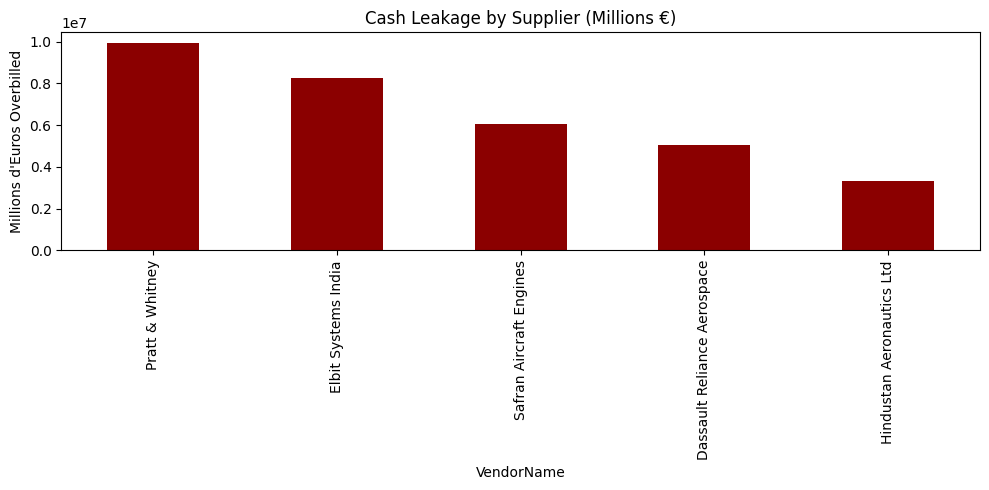


--- 3-WAY MATCH AUDIT ---
Detected 11 ghost invoices (payments for unreceived items).
Total Ghost Cost: 6.93 Million Euros.

Top 5 Ghost Invoices to Investigate:


,EBELN,VendorName,Qty_PO,Qty_Invoiced,Total_Qty_Received,Ghost_Cost_EUR
409,454500635,Safran Aircraft Engines,10,11,10,5552470.67
645,454501015,Pratt & Whitney,41,45,41,387353.12
185,454500295,Thales Group,35,39,35,349568.20
278,454500456,Collins Aerospace,37,40,37,226805.76
150,454500247,Safran Aircraft Engines,23,25,23,160598.08



--- AUDIT COMPLETE ---


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(po_path, inv_path, migo_path):
    """
    Loads the purchase orders, vendor invoices, and goods receipts data.

    Args:
        po_path (str): Path to the purchase orders CSV.
        inv_path (str): Path to the vendor invoices CSV.
        migo_path (str): Path to the goods receipts CSV.

    Returns:
        tuple: DataFrames for purchase orders, vendor invoices, and goods receipts.
    """
    df_po = pd.read_csv(po_path)
    df_inv = pd.read_csv(inv_path)
    df_migo = pd.read_csv(migo_path)
    return df_po, df_inv, df_migo

def perform_cash_leakage_audit(df_po, df_inv):
    """
    Performs a cash leakage audit by comparing invoiced amounts to purchase order values.

    Args:
        df_po (pd.DataFrame): DataFrame containing purchase order data.
        df_inv (pd.DataFrame): DataFrame containing vendor invoice data.

    Returns:
        tuple: DataFrame with audit results and top suppliers for cash leakage.
    """
    # Merge invoices with purchase orders to link invoices to order values
    df_audit = pd.merge(df_inv, df_po[['EBELN', 'VendorName', 'Total_Value_EUR']],
                        on='EBELN', how='inner')

    # Calculate the variance between invoiced amount and order value
    df_audit['Amount_Variance'] = df_audit['Amount_Invoice_EUR'] - df_audit['Total_Value_EUR']

    # Identify cash leakage (overbilling) where variance is positive
    df_audit['Cash_Leakage_EUR'] = df_audit['Amount_Variance'].apply(lambda x: x if x > 0 else 0)

    # Filter for fraudulent/overbilled invoices
    fraudes = df_audit[df_audit['Cash_Leakage_EUR'] > 0]
    total_leakage = fraudes['Cash_Leakage_EUR'].sum()

    # Identify top suppliers responsible for cash leakage
    top_leakage_suppliers = fraudes.groupby('VendorName')['Cash_Leakage_EUR'].sum().sort_values(ascending=False)

    print(f"\n--- CASH LEAKAGE AUDIT ---")
    print(f"Detected {len(fraudes)} invoices with overbilling.")
    print(f"Total Cash Leakage: {total_leakage / 1e6:.2f} Million Euros.")
    print(f"\nTop 3 Suppliers by Cash Leakage (Millions €):\n{top_leakage_suppliers.head(3) / 1e6}")

    # Plotting the top cash leakage suppliers
    fig = plt.figure(figsize=(10, 5))
    top_leakage_suppliers.head(5).plot(kind='bar', color='darkred', title="Cash Leakage by Supplier (Millions €)")
    plt.ylabel("Millions d'Euros Overbilled")
    plt.tight_layout()
    plt.show()

    return df_audit, fraudes

def perform_3way_match_audit(df_audit, df_migo):
    """
    Performs a 3-way match audit to detect 'ghost costs' (payments for unreceived items).

    Args:
        df_audit (pd.DataFrame): DataFrame from the cash leakage audit.
        df_migo (pd.DataFrame): DataFrame containing goods receipts data.

    Returns:
        pd.DataFrame: DataFrame of detected ghost invoices.
    """
    # Aggregate received quantities from goods receipts
    receptions = df_migo.groupby('EBELN')['Qty_Received'].sum().reset_index()
    receptions.rename(columns={'Qty_Received': 'Total_Qty_Received'}, inplace=True)

    # Merge audit data with aggregated goods receipts
    df_3way = pd.merge(df_audit, receptions, on='EBELN', how='left')

    # Fill NaN values (no goods receipts) with 0
    df_3way['Total_Qty_Received'] = df_3way['Total_Qty_Received'].fillna(0)

    # Identify 'ghost invoices' where invoiced quantity is greater than received quantity
    ghost_invoices = df_3way[df_3way['Qty_Invoiced'] > df_3way['Total_Qty_Received']].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Calculate the cost of unreceived items (ghost costs)
    ghost_invoices.loc[:, 'Ghost_Cost_EUR'] = (ghost_invoices['Qty_Invoiced'] - ghost_invoices['Total_Qty_Received']) * ghost_invoices['Unit_Price_PO_EUR']
    total_ghost_cost = ghost_invoices['Ghost_Cost_EUR'].sum()

    print(f"\n--- 3-WAY MATCH AUDIT ---")
    print(f"Detected {len(ghost_invoices)} ghost invoices (payments for unreceived items).")
    print(f"Total Ghost Cost: {total_ghost_cost / 1e6:.2f} Million Euros.")

    # Display top 5 ghost invoices for investigation
    columns_to_show = ['EBELN', 'VendorName', 'Qty_PO', 'Qty_Invoiced', 'Total_Qty_Received', 'Ghost_Cost_EUR']
    print("\nTop 5 Ghost Invoices to Investigate:")
    display(ghost_invoices[columns_to_show].sort_values(by='Ghost_Cost_EUR', ascending=False).head(5))

    return ghost_invoices


# --- Main Script Execution ---
print("--- FINANCIAL PROCURE-TO-PAY AUDIT ---")

# 1. Load Data
df_po_data, df_inv_data, df_migo_data = load_data(
    '/ERP_PurchaseOrders_MM.csv',
    '/ERP_VendorInvoices_MIRO.csv',
    '/ERP_GoodsReceipts_MIGO.csv'
)

# 2. Perform Cash Leakage Audit
df_audit_results, overbilled_invoices = perform_cash_leakage_audit(df_po_data, df_inv_data)

# 3. Perform 3-Way Match Audit
ghost_invoices_detected = perform_3way_match_audit(df_audit_results, df_migo_data)

print("\n--- AUDIT COMPLETE ---")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')